In [1]:
import scipy.linalg as la
import numpy as np
import copy
import time
import random
import matplotlib.pyplot as plt
import pandas as pd
import csv, ast
from qutip import *
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from qutip import qload
from joblib import load
from extracter import *
from fitting_model import *
import matplotlib as mpl
mpl.rcParams.update({
    "font.family": "Arial",          
    "font.size": 8,

    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3,
    "ytick.major.size": 3,

    "lines.linewidth": 1.5,
    "lines.markersize": 4,

    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,

    "pdf.fonttype": 42,   
    "ps.fonttype": 42,
    "svg.fonttype": "none"
})
rng = np.random.default_rng(43)
np.random.seed(43)
random.seed(43)

We start by analyzing the performance of one fold and analyze average 48 times

In [4]:
num_ft = 4
fold_num = 0
rep = 1

# load features
data = pd.read_csv(f"fold/{num_ft}fts{fold_num}_seed2_tau5.csv")
# load fold
y_train = load(f'LOO/fold_{fold_num}_seed2.joblib')['y_train'] # unload y_train
target_train = [int(i) for i in y_train][::num_ft] # store y_train while skipping the repetition
y_test = load(f'LOO/fold_{fold_num}_seed2.joblib')['y_test'] # unload y_test
target_test = [int(i) for i in y_test][::num_ft] # store y_test while skipping the repetition
target_train.extend(target_test) # combine y_train,y_test as one

len(target_train)

48

In [6]:
# training parameters
delay_points = 1
train_points = 46
total_points = 48

In [8]:
X = extract_block_single_column_pq(data ,column_name="PQ0",N_fts=num_ft,n_samples=48,skip_steps=rep)
X_train = X[delay_points:train_points+delay_points]
X_test = X[train_points+delay_points:]

y_train = target_train[delay_points:train_points+delay_points] # separate into train and test
y_test = target_train[train_points+delay_points:]
W = fitting_function(X_train, y_train) # find the weight matrix
y_prediction = predict(X_test, W) # find the final prediction

y_train_pred = predict(X_train, W) # find the final prediction

y_pred = np.concatenate(([0],y_train_pred, y_prediction)) # the first two were used for delay
X_train.shape

(46, 8)

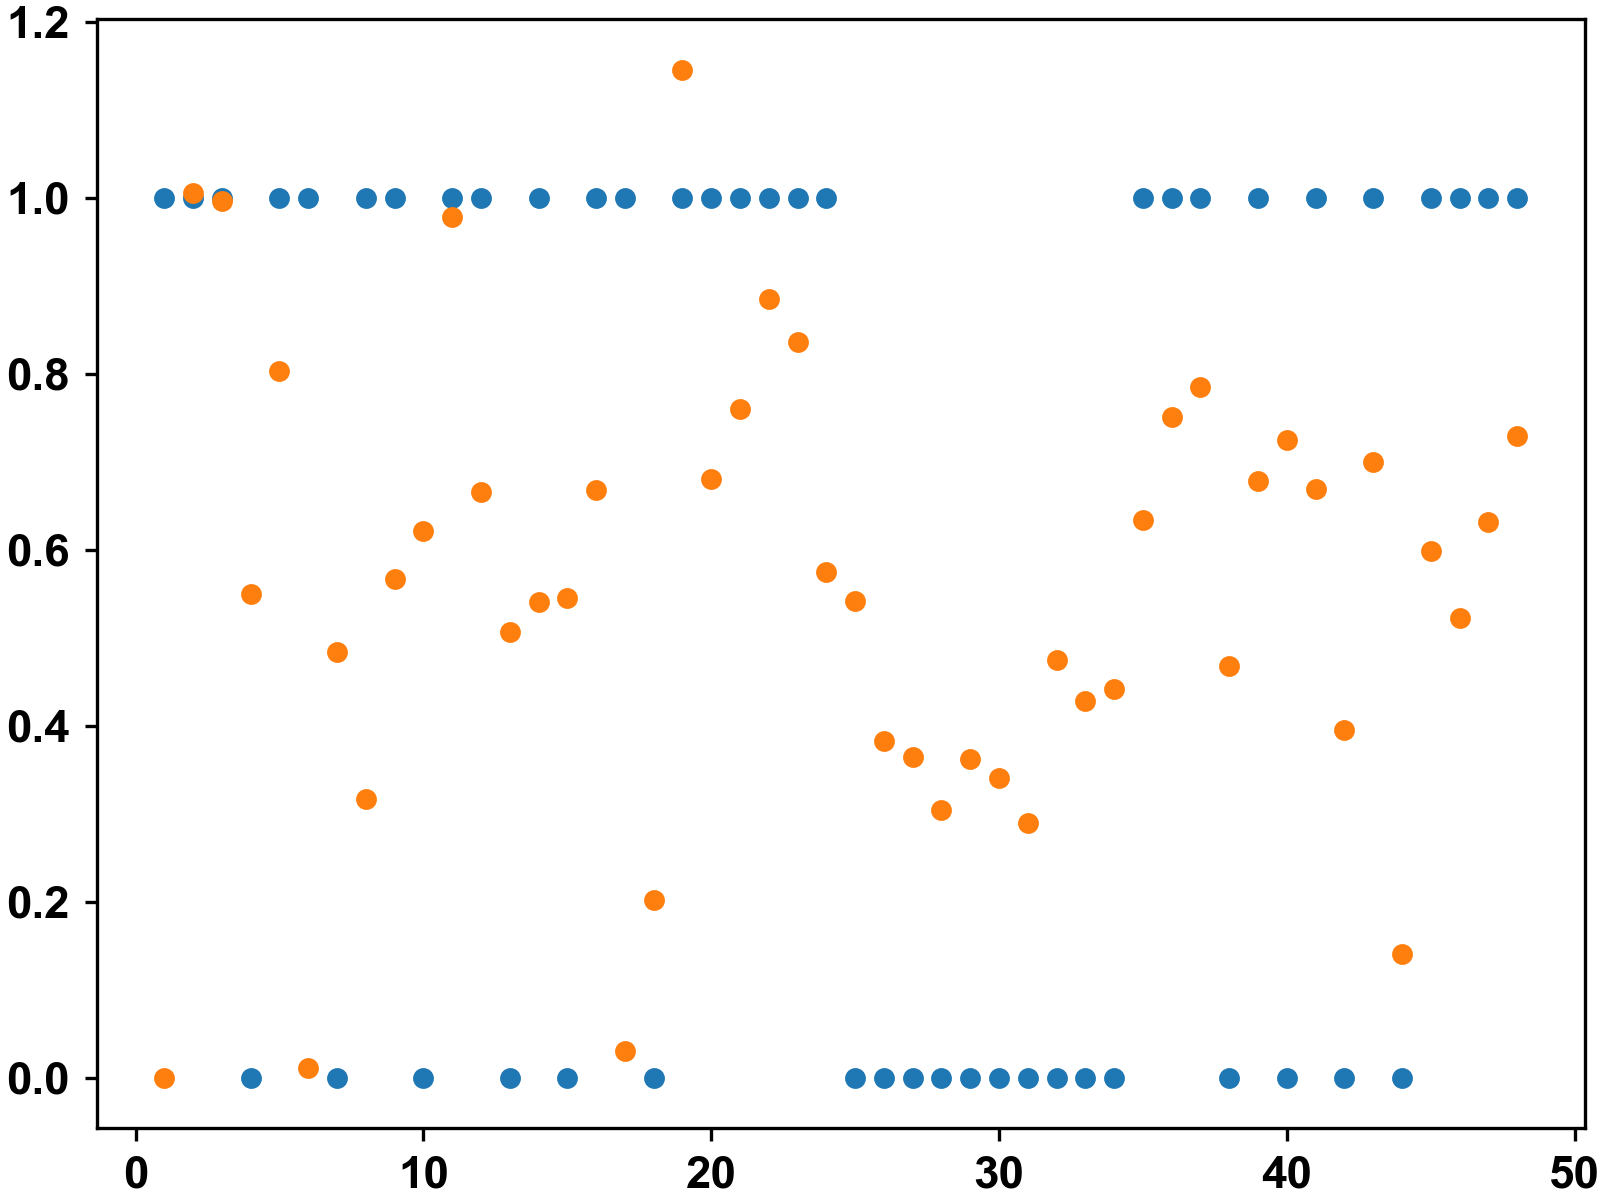

In [10]:
x = np.linspace(1,48,48)
plt.scatter(x,target_train)
plt.scatter(x,y_pred)

In [36]:
predictions = []
real_answers = []
y_pred_value = float(np.asarray(y_prediction).squeeze())
# threshold classification
if y_pred_value < 0.5:
    y_pred_class = 0
else:
    y_pred_class = 1

predictions.append(y_pred_class)
real_answers.append(int(np.asarray(y_test).squeeze()))
print("Predictions: ", predictions)
print("Real Answers: ", real_answers)

Predictions:  [1]
Real Answers:  [1]


Analyze the full set

In [24]:
num_ft = 4
rep = 1
delay_points = 1
train_points = 46
total_points = 48
predictions = []
real_answers = []
for seed in [0,1,2,3]:
    for fold_num in range(0,48): 
        # load features
        data = pd.read_csv(f"fold/{num_ft}fts{fold_num}_seed{seed}_tau10.csv") # REPLACE here tau5<->tau10
        # load fold
        y_train = load(f'LOO/fold_{fold_num}_seed{seed}.joblib')['y_train'] # unload y_train
        target_train = [int(i) for i in y_train][::num_ft] # store y_train while skipping the repetition
        y_test = load(f'LOO/fold_{fold_num}_seed{seed}.joblib')['y_test'] # unload y_test
        target_test = [int(i) for i in y_test][::num_ft] # store y_test while skipping the repetition
        target_train.extend(target_test) # combine y_train,y_test as one
    
        # Features splitting
        X = extract_block_single_column_pq(data ,column_name="PQ0",N_fts=num_ft, mode="both",n_samples=48,skip_steps=rep)
        X_train = X[delay_points:train_points+delay_points]
        X_test = X[train_points+delay_points:]
        # Target splitting
        y_train = target_train[delay_points:train_points+delay_points] # separate into train and test
        y_test = target_train[train_points+delay_points:]
        W = fitting_function(X_train, y_train) # find the weight matrix
        y_prediction = predict(X_test, W) # find the final prediction
    
        # adding to the total evaluation
        y_pred_value = float(np.asarray(y_prediction).squeeze())
        # threshold classification
        if y_pred_value < 0.5:
            y_pred_class = 0
        else:
            y_pred_class = 1
        
        predictions.append(y_pred_class)
        real_answers.append(int(np.asarray(y_test).squeeze()))
    
    print("Predictions: ", predictions)
    print(len(real_answers))
    substitution = 0
    for i in range(len(real_answers)):
        if real_answers[i] != predictions[i]:
            substitution += 1
    Accuracy = substitution / len(real_answers)
    print(f"Our quantum model obtains an accuracy of {(1-Accuracy)*100}%")

    predictions = []
    real_answers = []

Predictions:  [1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1]
48
Our quantum model obtains an accuracy of 79.16666666666666%
Predictions:  [1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1]
48
Our quantum model obtains an accuracy of 81.25%
Predictions:  [1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1]
48
Our quantum model obtains an accuracy of 70.83333333333333%
Predictions:  [1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1]
48
Our quantum model obtains an accuracy of 81.25%
